# Isolation Forest — Route (b): Features + Feature Selection

In [1]:
import sys, time
sys.path.append(r"C:\Projects\anomaly-detection\Modeling\Code")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from numpy.lib.stride_tricks import sliding_window_view
from sklearn.ensemble import IsolationForest
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import average_precision_score
from eval_protocol import time_split_per_kpi, evaluate_protocol, plot_pr_curve
from preprocess import preprocess_all

## 1. Doc KPI -> split thoi gian -> tien xu ly

In [2]:
KPI_PREFIX = "02e99bd4"
df = pd.read_csv(r"C:\Projects\anomaly-detection\Data\train.csv")
df.columns = ["timestamp", "value", "label", "kpi"]
kpi = [k for k in df.kpi.unique() if k.startswith(KPI_PREFIX)][0]
g = df[df.kpi == kpi].copy()
step = int(pd.Series(np.diff(np.sort(g.timestamp.values))).mode().iloc[0])
g = time_split_per_kpi(g, train_frac=0.6, val_frac=0.2)
p = preprocess_all(g, max_gap_points=5, norm_method="robust").sort_values("timestamp").reset_index(drop=True)

x = p.value_filled.astype(float); ts = p.timestamp.values; masked = p.masked.values
spl = p.split.values; lab = p.label.values.astype(int); tr_rows = (spl == "train")
print("KPI:", kpi, "| diem:", len(p), "| step:", step)

KPI: 02e99bd4f6cfb33f | diem: 131795 | step: 60


## 2. Feature Engineering
§1 lag - §2 rolling mean/std/min/max (5/15/60) + do lech baseline - §3 rate-of-change - §4 residual khu mua vu - §6 time encoding. (§5 cross-metric bo vi univariate.)

In [3]:
F = pd.DataFrame(index=p.index)
F["value"] = x
for L in [1, 5, 10, 60]:
    F[f"lag_{L}"] = x.shift(L)
for w in [5, 15, 60]:
    r = x.rolling(w)
    F[f"rmean_{w}"] = r.mean(); F[f"rstd_{w}"] = r.std()
    F[f"rmin_{w}"]  = r.min();  F[f"rmax_{w}"] = r.max()
    F[f"dev_{w}"]   = x - r.mean()
F["diff_1"] = x.diff(1)
F["pct_1"]  = (x.diff(1) / (x.shift(1).abs() + 1e-6)).clip(-50, 50)
xi = x.interpolate(limit_direction="both").bfill().ffill()
trend = xi.rolling(1440, center=True, min_periods=200).median()
mod = ((ts % 86400) // 60).astype(int)
seasonal = (xi - trend).groupby(mod).transform("median")
resid = (xi - trend - seasonal); resid[masked] = np.nan
F["deseason_resid"] = resid.values
tod = (ts % 86400) / 86400.0; dow = ((ts // 86400) % 7) / 7.0
F["tod_sin"] = np.sin(2*np.pi*tod); F["tod_cos"] = np.cos(2*np.pi*tod)
F["dow_sin"] = np.sin(2*np.pi*dow); F["dow_cos"] = np.cos(2*np.pi*dow)
print("Tong feature tho:", F.shape[1])

Tong feature tho: 27


## 3. Feature Selection

In [4]:
Xtr = F[tr_rows]
cv = (Xtr.std() / (Xtr.mean().abs() + 1e-9)).abs()
drop_var = cv[cv < 0.01].index.tolist()
keep = [c for c in F.columns if c not in drop_var]
mtr = tr_rows & F[keep].notna().all(axis=1).values
mi = pd.Series(mutual_info_classif(F.loc[mtr, keep], lab[mtr], random_state=0), index=keep)
corr = F.loc[tr_rows, keep].corr().abs(); drop_corr = set(); pairs = []; cols = list(keep)
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        a, b = cols[i], cols[j]
        if a in drop_corr or b in drop_corr:
            continue
        if corr.loc[a, b] > 0.95:
            loser, winner = (a, b) if mi[a] < mi[b] else (b, a)
            drop_corr.add(loser)
            pairs.append(dict(giu=winner, loai=loser, r=round(corr.loc[a, b], 3),
                              MI_giu=round(mi[winner], 4), MI_loai=round(mi[loser], 4)))
keep2 = [c for c in keep if c not in drop_corr]
mi2 = mi[keep2].sort_values(ascending=False)
FINAL = mi2[mi2 > 1e-4].index.tolist()
print(f"B1 loai {len(drop_var)} | B2 loai {len(drop_corr)} | B3 giu {len(FINAL)}/{F.shape[1]}")

B1 loai 0 | B2 loai 8 | B3 giu 19/27


## 3.1 Output: Tap Feature Curated 

In [11]:
KEEP_INTERP = ["tod_sin", "tod_cos", "dow_sin", "dow_cos", "deseason_resid", "pct_1"]

b1 = pd.DataFrame({"feature": cv.index, "CV": cv.values, "loai_B1": cv.index.isin(drop_var)}).sort_values("CV")
print("### (1) Variance/CV - feature gan hang so (CV<0.01):",
      drop_var if drop_var else "KHONG co (moi feature deu bien dong du)")

b2 = pd.DataFrame(pairs).sort_values("r", ascending=False) if pairs else pd.DataFrame()
print("\n### (2) Correlation |r|>0.95 - cap bi loai (giu feature MI cao hon):")
print(b2.to_string(index=False) if len(b2) else "  (khong co cap nao)")

b3 = pd.DataFrame({"feature": mi2.index, "MI": mi2.values})
b3["giu"] = b3.feature.isin(FINAL)
b3["ghi_chu"] = np.where(b3.feature.isin(KEEP_INTERP), "giu vi dien giai/ngu canh", "")
print("\n### (3) MI ranking (tap curated cuoi cung):")
print(b3.to_string(index=False))

print("\n### (3) Ghi chu:")
print("  - Top MI la rolling std/max cua so lon -> anomaly KPI nay mang tinh BIEN DONG/pattern.")
print("  - Giu tod/dow (MI thap) vi cung cap ngu canh chu ky, bo tro deseason_resid.")
print("  - Han che: correlation filter tham lam theo cap (vd value vua thang lag_1 vua thua rmean_5)")

import os
os.makedirs("FE_FS", exist_ok=True)
out_md = f"FE_FS/curated_{kpi[:8]}.md"
def to_md(dfr):
    try: return dfr.to_markdown(index=False)
    except Exception: return dfr.to_string(index=False)
with open(out_md, "w", encoding="utf-8") as fh:
    fh.write(f"# Curated features - KPI {kpi} ({len(FINAL)} feature)\n\n")
    fh.write("## B1 Variance\n" + (", ".join(drop_var) if drop_var else "Khong loai feature nao.") + "\n\n")
    fh.write("## B2 Correlation (cap bi loai)\n\n" + (to_md(b2) if len(b2) else "(khong co)") + "\n\n")
    fh.write("## B3 MI ranking\n\n" + to_md(b3) + "\n")
b3[b3.giu].to_csv(f"FE_FS/curated_{kpi[:8]}.csv", index=False)
print(f"\n[saved] {out_md}  &  FE_FS/curated_{kpi[:8]}.csv")

### (1) Variance/CV - feature gan hang so (CV<0.01): KHONG co (moi feature deu bien dong du)

### (2) Correlation |r|>0.95 - cap bi loai (giu feature MI cao hon):
     giu     loai     r  MI_giu  MI_loai
 rmean_5   rmin_5 0.979  0.0767   0.0627
rmean_15 rmean_60 0.973  0.0808   0.0729
  rmax_5  rmean_5 0.969  0.0996   0.0767
rmean_15  rmin_15 0.968  0.0808   0.0680
 rmean_5    value 0.964  0.0767   0.0655
rmean_15    lag_5 0.957  0.0808   0.0642
rmean_15   lag_10 0.956  0.0808   0.0592
   value    lag_1 0.950  0.0655   0.0653

### (3) MI ranking (tap curated cuoi cung):
       feature       MI  giu                   ghi_chu
       rstd_60 0.229432 True                          
       rmax_60 0.203596 True                          
       rstd_15 0.183649 True                          
       rmax_15 0.138442 True                          
        rstd_5 0.105785 True                          
        rmax_5 0.099650 True                          
        dev_15 0.086765 True          

## 4. Isolation Forest tren feature curated — multi-seed + so voi route (a)

In [9]:
Xall = F[FINAL].values
valid = ~np.isnan(Xall).any(axis=1)

seeds = [0, 1, 2, 3, 4]; rows = []
for sd in seeds:
    clf = IsolationForest(n_estimators=100, max_samples=512,
                          contamination="auto", random_state=sd).fit(Xall[tr_rows & valid])
    sc = -clf.decision_function(Xall)
    vm, tm = (spl == "val") & valid, (spl == "test") & valid
    r = evaluate_protocol(lab[vm], sc[vm], lab[tm], sc[tm], beta=1.0, step_s=step)
    rows.append((r["PW"]["fbeta"], r["PA"]["fbeta"], r["AP_pw"]))
b = np.array(rows).mean(0); bstd = np.array(rows).std(0)
print(f"[route b] PW_F1={b[0]:.3f}+/-{bstd[0]:.3f}  PA_F1={b[1]:.3f}+/-{bstd[1]:.3f}  AP={b[2]:.3f}+/-{bstd[2]:.3f}")

v = p.value_norm.values.astype(float)
def make_shingles(s):
    W = sliding_window_view(v, s); cur = np.arange(s-1, len(v)); ok = ~np.isnan(W).any(axis=1)
    return W[ok], lab[cur][ok], spl[cur][ok]
Xs, ys, sps = make_shingles(48)
clf = IsolationForest(n_estimators=100, max_samples=512, contamination="auto", random_state=0).fit(Xs[sps=="train"])
scs = -clf.decision_function(Xs)
ra = evaluate_protocol(ys[sps=="val"], scs[sps=="val"], ys[sps=="test"], scs[sps=="test"], beta=1.0, step_s=step)
print(f"[route a] PW_F1={ra['PW']['fbeta']:.3f}          PA_F1={ra['PA']['fbeta']:.3f}          AP={ra['AP_pw']:.3f}")

[route b] PW_F1=0.754+/-0.019  PA_F1=0.978+/-0.025  AP=0.885+/-0.003
[route a] PW_F1=0.674          PA_F1=0.815          AP=0.796


## 5. PR curve so sanh route (a) vs (b)

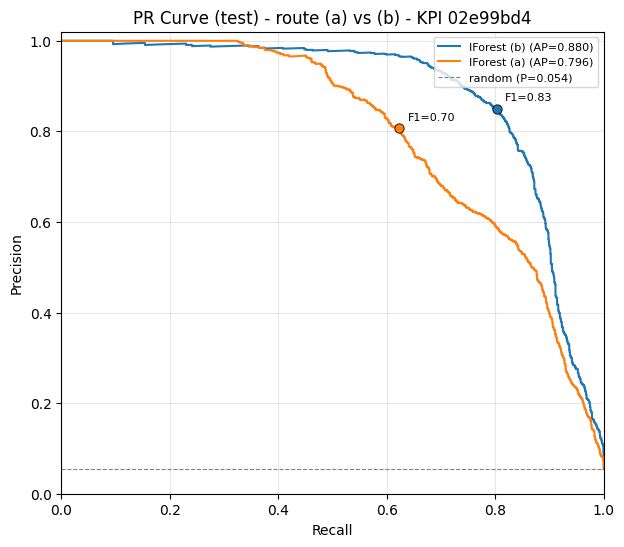

In [10]:
tm = (spl == "test") & valid
te_s = sps == "test"
ax = plot_pr_curve({"IForest (b)":   (lab[tm], sc[tm]),
                    "IForest (a)": (ys[te_s], scs[te_s])},
                   title=f"PR Curve (test) - route (a) vs (b) - KPI {kpi[:8]}")
plt.show()